# Hypothesis Testing in Python
## t-tests, ANOVA, and Statistical Decision Making

### What is Hypothesis Testing?

**Hypothesis testing** is a formal procedure for investigating our ideas about the world using statistics. It lets us decide whether observed patterns in data reflect true effects or just random noise.

### The Two Competing Hypotheses

| Hypothesis | Symbol | Meaning |
|-----------|--------|---------|
| **Null Hypothesis** | $H_0$ | No effect, no difference, or no relationship |
| **Alternative Hypothesis** | $H_1$ | There is an effect, a difference, or a relationship |

> We assume $H_0$ is true and ask: *"How surprising is our data if $H_0$ were actually true?"*

### Key Concepts

- **Significance Level ($\alpha$)**: The threshold for "surprising" (commonly 0.05)
- **p-value**: The probability of observing data at least as extreme as ours, assuming $H_0$ is true
- **Test Statistic**: A standardized score (t, F, z) measuring how far our data deviates from $H_0$
- **Decision Rule**: If $p < \alpha$, **reject $H_0$**; otherwise, **fail to reject $H_0$**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy
import pandas as pd

# Statsmodels for ANOVA, post-hoc, and power
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower

np.random.seed(42)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")


Libraries loaded successfully!
NumPy version: 2.4.3
SciPy version: 1.17.1


## 1. Type I Error, Type II Error, and Statistical Power

When we test hypotheses, we can make two kinds of mistakes:

| Decision | $H_0$ is True | $H_0$ is False |
|----------|---------------|----------------|
| **Reject $H_0$** | Type I Error ($\alpha$) | Correct (Power = $1-\beta$) |
| **Fail to reject $H_0$** | Correct ($1-\alpha$) | Type II Error ($\beta$) |

- **Type I Error ($\alpha$)**: False positive — detecting an effect that isn't there
- **Type II Error ($\beta$)**: False negative — missing an effect that is there
- **Power ($1-\beta$)**: The probability of correctly detecting a true effect

### The Trade-off
Decreasing $\alpha$ (being more conservative) increases $\beta$ (reduces power), unless you increase sample size.


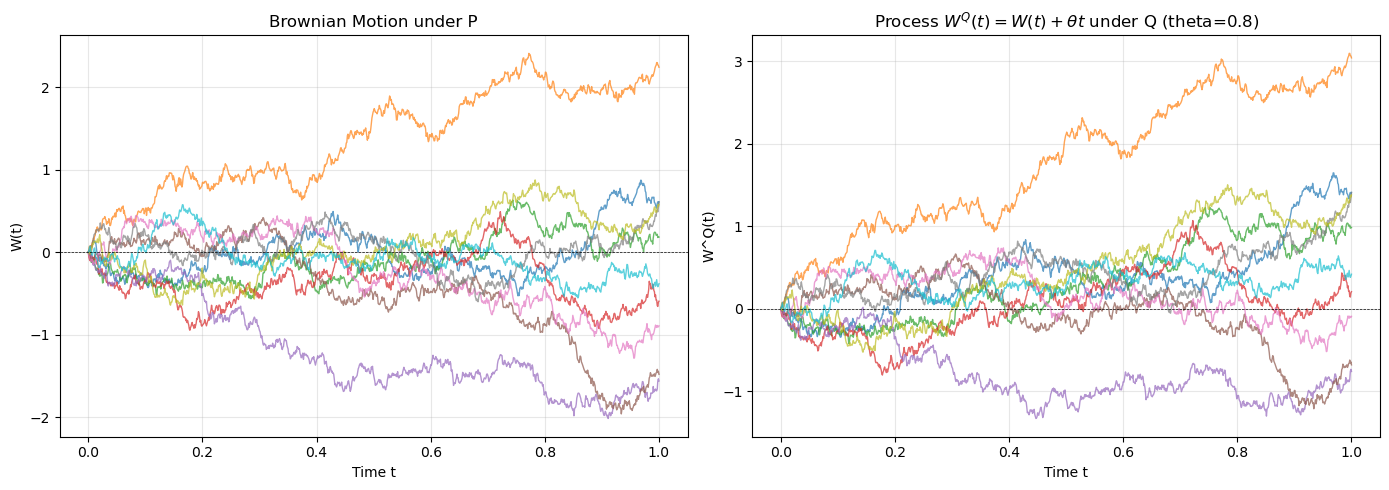

In [2]:
# Parameters for H0 and H1 distributions
mu0 = 100      # Null hypothesis mean
mu1 = 105      # Alternative mean
sigma = 10
n = 25
alpha = 0.05

# Standard error of the mean
se = sigma / np.sqrt(n)

# Critical values for two-tailed test under H0
z_crit = stats.norm.ppf(1 - alpha / 2)
x_crit_right = mu0 + z_crit * se
x_crit_left = mu0 - z_crit * se

# X-axis range
x = np.linspace(mu0 - 4*se, mu1 + 4*se, 1000)

# Sampling distributions under H0 and H1
y_h0 = stats.norm.pdf(x, mu0, se)
y_h1 = stats.norm.pdf(x, mu1, se)

fig, ax = plt.subplots(figsize=(10, 6))

# H0 distribution with rejection regions
ax.plot(x, y_h0, 'b-', lw=2, label=rf'$H_0: \mu = {mu0}$')
ax.fill_between(x, y_h0, where=((x <= x_crit_left) | (x >= x_crit_right)),
                alpha=0.3, color='red', label=rf'Rejection Region ($\alpha = {alpha}$)')

# H1 distribution
ax.plot(x, y_h1, 'g-', lw=2, label=rf'$H_1: \mu = {mu1}$')

# Type II error (beta) — area under H1 in non-rejection region
x_beta = x[(x >= x_crit_left) & (x <= x_crit_right)]
y_beta = stats.norm.pdf(x_beta, mu1, se)
ax.fill_between(x_beta, y_beta, alpha=0.3, color='orange', label='Type II Error ($\\beta$)')

# Power — area under H1 in rejection regions
x_pwr_right = x[x >= x_crit_right]
y_pwr_right = stats.norm.pdf(x_pwr_right, mu1, se)
x_pwr_left = x[x <= x_crit_left]
y_pwr_left = stats.norm.pdf(x_pwr_left, mu1, se)
ax.fill_between(x_pwr_right, y_pwr_right, alpha=0.3, color='green', label='Power ($1-\\beta$)')
ax.fill_between(x_pwr_left, y_pwr_left, alpha=0.3, color='green')

# Critical value lines
ax.axvline(x_crit_right, color='red', linestyle='--', lw=1.5)
ax.axvline(x_crit_left, color='red', linestyle='--', lw=1.5)

ax.set_xlabel('Sample Mean', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Type I Error, Type II Error, and Statistical Power', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('type_errors_power.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate beta and power
beta = stats.norm.cdf(x_crit_right, mu1, se) - stats.norm.cdf(x_crit_left, mu1, se)
print(f"Critical values: [{x_crit_left:.2f}, {x_crit_right:.2f}]")
print(f"Type I error rate (alpha): {alpha}")
print(f"Type II error rate (beta): {beta:.4f}")
print(f"Power (1-beta): {1-beta:.4f}")


## 2. One-Sample t-test

Use this when you want to compare the mean of a **single sample** to a known or hypothesized value.

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

### When to use it
- One group of observations
- Population standard deviation $\sigma$ is **unknown**
- Data are approximately normally distributed (or $n \geq 30$ by CLT)

### Interpretation
- A large $|t|$ means the sample mean is far from $\mu_0$ relative to the sampling variability
- The p-value tells us how extreme this t-statistic is under the null distribution
- 

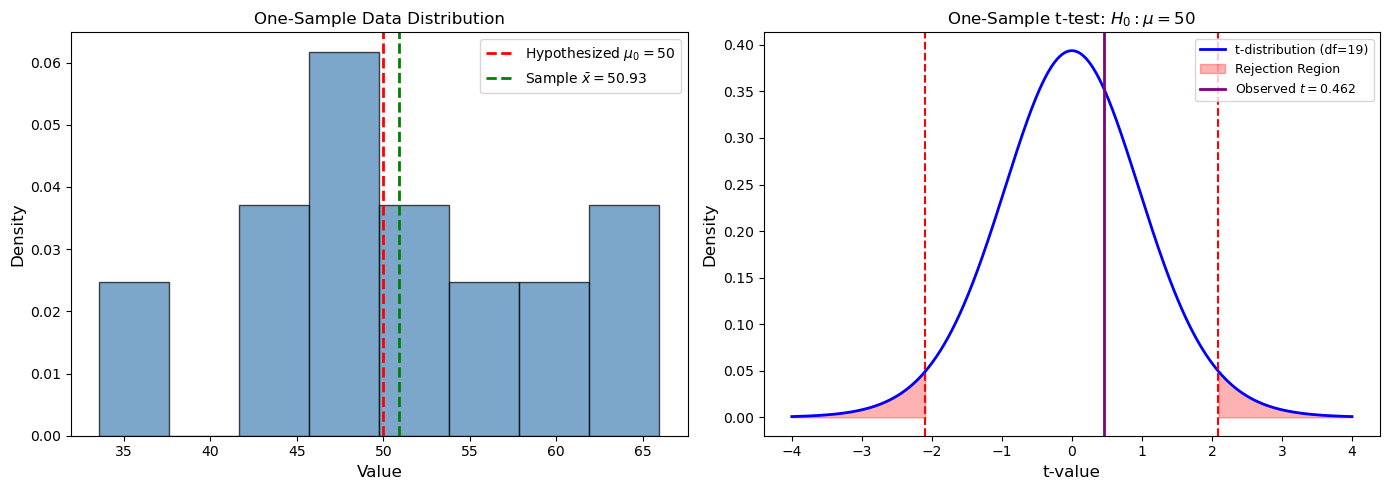

Sample mean: 50.9331
Sample std: 9.0270
t-statistic: 0.4623 (manual: 0.4623)
p-value (two-tailed): 0.6491
95% CI: [46.7083, 55.1579]
Decision at alpha=0.05: Fail to reject H0


In [7]:
# Generate sample data
np.random.seed(1)
mu_true = 52
sigma = 8
n = 20
data = np.random.normal(mu_true, sigma, n)

# Hypothesized mean under H0
mu_hyp = 50

# Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(data, mu_hyp)

# Manual verification
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)
se = sample_std / np.sqrt(n)
t_manual = (sample_mean - mu_hyp) / se
df = n - 1

# 95% Confidence interval
t_crit = stats.t.ppf(0.975, df)
ci_lower = sample_mean - t_crit * se
ci_upper = sample_mean + t_crit * se

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data with hypothesized mean
ax1 = axes[0]
ax1.hist(data, bins=8, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(mu_hyp, color='red', linestyle='--', lw=2, label=rf'Hypothesized $\mu_0 = {mu_hyp}$')
ax1.axvline(sample_mean, color='green', linestyle='--', lw=2, label=rf'Sample $\bar{{x}} = {sample_mean:.2f}$')
ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('One-Sample Data Distribution', fontsize=12)
ax1.legend()

# Plot 2: t-distribution under H0
ax2 = axes[1]
x_t = np.linspace(-4, 4, 1000)
y_t = stats.t.pdf(x_t, df)
ax2.plot(x_t, y_t, 'b-', lw=2, label=rf't-distribution (df={df})')

# Rejection regions (two-tailed)
t_crit_val = stats.t.ppf(0.975, df)
x_rej_left = x_t[x_t <= -t_crit_val]
x_rej_right = x_t[x_t >= t_crit_val]
ax2.fill_between(x_rej_left, stats.t.pdf(x_rej_left, df), alpha=0.3, color='red', label='Rejection Region')
ax2.fill_between(x_rej_right, stats.t.pdf(x_rej_right, df), alpha=0.3, color='red')

# Observed statistic
ax2.axvline(t_stat, color='purple', lw=2, label=rf'Observed $t = {t_stat:.3f}$')
ax2.axvline(-t_crit_val, color='red', linestyle='--', lw=1.5)
ax2.axvline(t_crit_val, color='red', linestyle='--', lw=1.5)

ax2.set_xlabel('t-value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(rf'One-Sample t-test: $H_0: \mu = {mu_hyp}$', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('one_sample_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample std: {sample_std:.4f}")
print(f"t-statistic: {t_stat:.4f} (manual: {t_manual:.4f})")
print(f"p-value (two-tailed): {p_value:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Decision at alpha=0.05: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")


## 3. Two-Sample t-test (Independent)

Compares the means of **two unrelated groups**.

### Student's t-test (Equal Variances Assumed)

$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}$$

where $s_p$ is the pooled standard deviation.

### Welch's t-test (Unequal Variances — Recommended)

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

> **Rule of thumb**: If sample sizes are similar and variances are within a 2:1 ratio, Student's t-test is fine. Otherwise, always use Welch's t-test (the default in many modern packages).


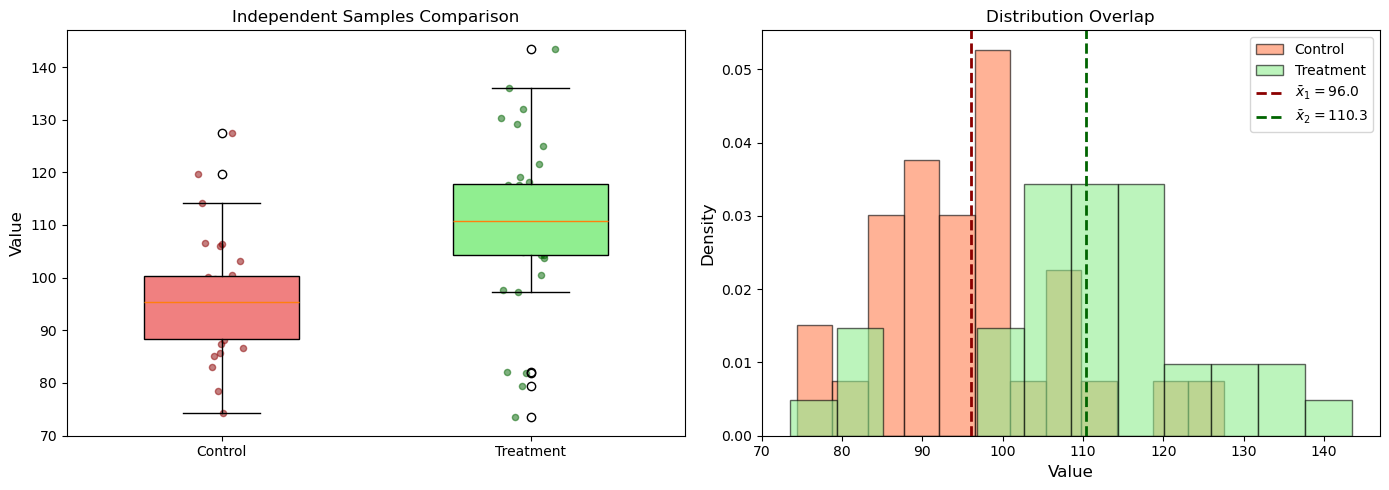

Control: n=30, mean=96.029, std=11.597
Treatment: n=35, mean=110.320, std=15.537
Student's t-test: t=-4.1433, p=0.0001
Welch's t-test:   t=-4.2364, p=0.0001
Cohen's d: 1.0309


In [8]:
# Generate two independent samples
np.random.seed(2)
group1 = np.random.normal(100, 12, 30)   # Control
group2 = np.random.normal(110, 15, 35)   # Treatment

# Equal variances assumed (Student's t-test)
t_eq, p_eq = stats.ttest_ind(group1, group2, equal_var=True)
# Unequal variances (Welch's t-test)
t_welch, p_welch = stats.ttest_ind(group1, group2, equal_var=False)

# Descriptive statistics
mean1, mean2 = np.mean(group1), np.mean(group2)
std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)

# Cohen's d (pooled)
pooled_std = np.sqrt(((len(group1)-1)*std1**2 + (len(group2)-1)*std2**2) / (len(group1)+len(group2)-2))
cohens_d = (mean2 - mean1) / pooled_std

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplots with individual points
ax1 = axes[0]
bp = ax1.boxplot([group1, group2], tick_labels=['Control', 'Treatment'],
                  patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')

# Jittered individual points
np.random.seed(3)
j1 = np.random.normal(1, 0.04, len(group1))
j2 = np.random.normal(2, 0.04, len(group2))
ax1.scatter(j1, group1, alpha=0.5, s=20, color='darkred')
ax1.scatter(j2, group2, alpha=0.5, s=20, color='darkgreen')

ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Independent Samples Comparison', fontsize=12)

# Plot 2: Overlapping histograms
ax2 = axes[1]
ax2.hist(group1, bins=12, density=True, alpha=0.6, color='coral', edgecolor='black', label='Control')
ax2.hist(group2, bins=12, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Treatment')
ax2.axvline(mean1, color='darkred', linestyle='--', lw=2, label=rf'$\bar{{x}}_1 = {mean1:.1f}$')
ax2.axvline(mean2, color='darkgreen', linestyle='--', lw=2, label=rf'$\bar{{x}}_2 = {mean2:.1f}$')
ax2.set_xlabel('Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution Overlap', fontsize=12)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('two_sample_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Control: n={len(group1)}, mean={mean1:.3f}, std={std1:.3f}")
print(f"Treatment: n={len(group2)}, mean={mean2:.3f}, std={std2:.3f}")
print(f"Student's t-test: t={t_eq:.4f}, p={p_eq:.4f}")
print(f"Welch's t-test:   t={t_welch:.4f}, p={p_welch:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")


## 4. Paired t-test

Used when the two sets of measurements come from the **same subjects** (e.g., before vs. after a treatment).

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

where $\bar{d}$ is the mean of the paired differences and $s_d$ is the standard deviation of those differences.

### Why paired?
Paired designs control for between-subject variability, making them more powerful than independent designs for the same sample size. Each subject serves as their own control.


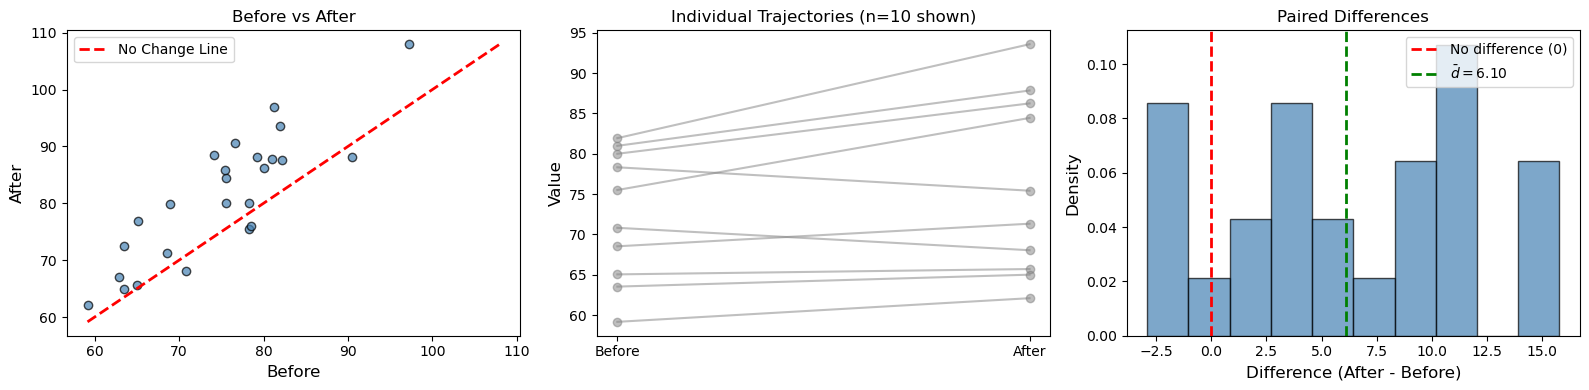

Mean difference: 6.1044
Std of differences: 5.6910
Paired t-statistic: -5.3632
p-value: 0.0000
Decision at alpha=0.05: Reject H0


In [9]:
# Generate paired data
np.random.seed(4)
n_subjects = 25
before = np.random.normal(75, 10, n_subjects)
improvement = np.random.normal(5, 4, n_subjects)
after = before + improvement + np.random.normal(0, 3, n_subjects)

# Paired t-test
t_paired, p_paired = stats.ttest_rel(before, after)
diff = after - before
mean_diff = np.mean(diff)
std_diff = np.std(diff, ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Before vs After scatter
ax1 = axes[0]
ax1.scatter(before, after, alpha=0.7, color='steelblue', edgecolors='black')
min_val = min(before.min(), after.min())
max_val = max(before.max(), after.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='No Change Line')
ax1.set_xlabel('Before', fontsize=12)
ax1.set_ylabel('After', fontsize=12)
ax1.set_title('Before vs After', fontsize=12)
ax1.legend()

# Plot 2: Connected lines (first 10 subjects)
ax2 = axes[1]
for i in range(min(10, n_subjects)):
    ax2.plot([0, 1], [before[i], after[i]], 'o-', color='gray', alpha=0.5)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'])
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title(f'Individual Trajectories (n={min(10, n_subjects)} shown)', fontsize=12)

# Plot 3: Distribution of differences
ax3 = axes[2]
ax3.hist(diff, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', lw=2, label='No difference (0)')
ax3.axvline(mean_diff, color='green', linestyle='--', lw=2, label=rf'$\bar{{d}} = {mean_diff:.2f}$')
ax3.set_xlabel('Difference (After - Before)', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Paired Differences', fontsize=12)
ax3.legend()

plt.tight_layout()
plt.savefig('paired_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean difference: {mean_diff:.4f}")
print(f"Std of differences: {std_diff:.4f}")
print(f"Paired t-statistic: {t_paired:.4f}")
print(f"p-value: {p_paired:.4f}")
print(f"Decision at alpha=0.05: {'Reject H0' if p_paired < 0.05 else 'Fail to reject H0'}")


## 5. Checking Assumptions

Parametric tests (t-tests, ANOVA) rely on assumptions. Violations can lead to invalid conclusions.

### 1. Normality
The data (or residuals) should be approximately normally distributed.
- **Shapiro-Wilk test**: $H_0$ = data comes from a normal distribution
- **Q-Q plot**: Visual check for normality

### 2. Homogeneity of Variance
Groups should have roughly equal variances.
- **Levene's test**: $H_0$ = equal variances across groups

### 3. Independence
Observations must be independent of each other. This is ensured by study design, not statistics.

> If assumptions are severely violated, consider non-parametric alternatives (Mann-Whitney U, Wilcoxon signed-rank, Kruskal-Wallis).


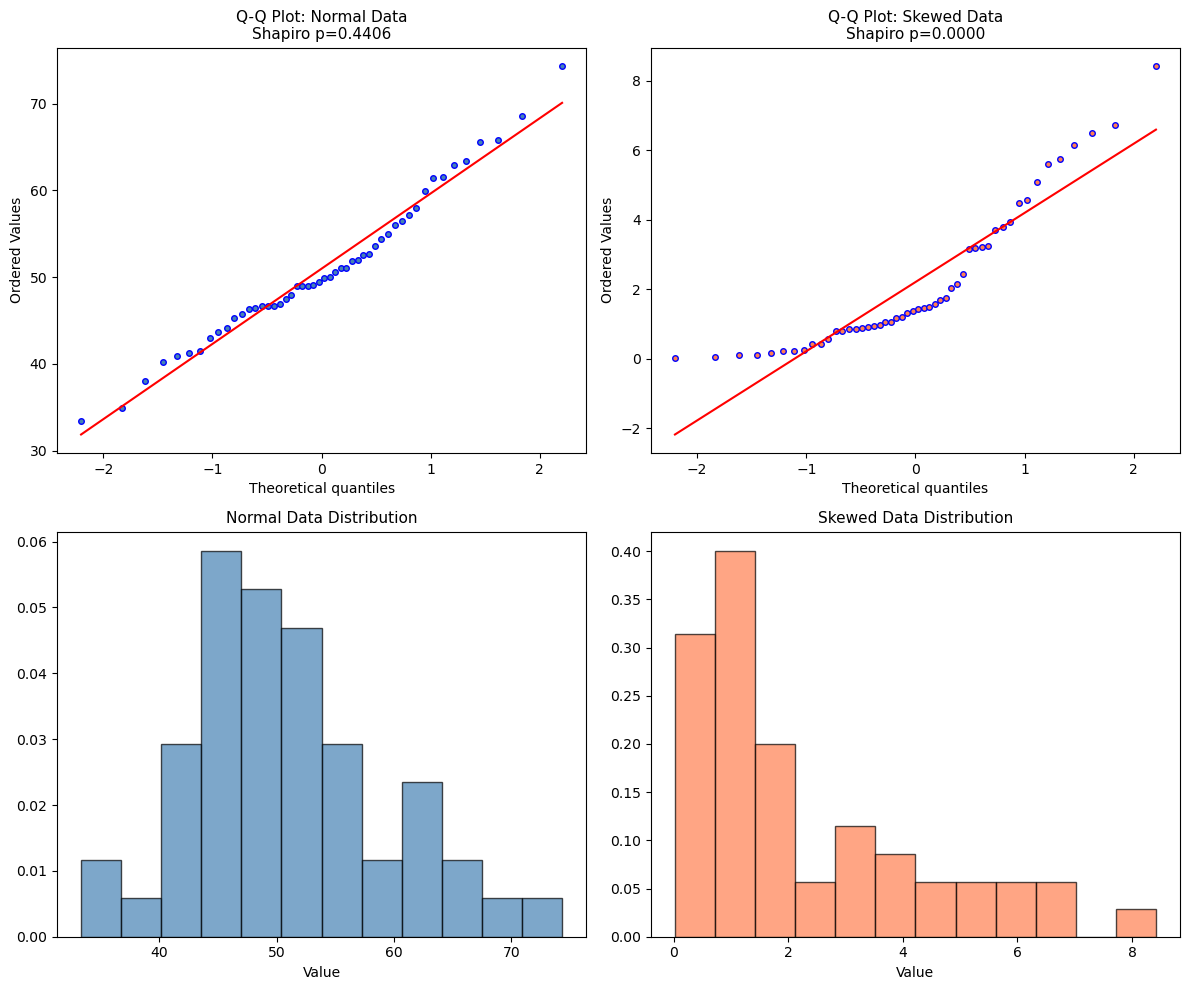

Shapiro-Wilk (normal): W=0.9772, p=0.4406
Shapiro-Wilk (skewed): W=0.8576, p=0.0000
Levene's test: W=29.2504, p=0.0000

Interpretation:
- Shapiro: p > 0.05 suggests data is consistent with normality
- Levene: p > 0.05 suggests equal variances (homoscedasticity)


In [10]:
np.random.seed(5)
normal_data = np.random.normal(50, 10, 50)
skewed_data = np.random.exponential(2, 50)

# Shapiro-Wilk tests
shapiro_normal = stats.shapiro(normal_data)
shapiro_skewed = stats.shapiro(skewed_data)

# Levene's test for equal variances
group_a = np.random.normal(100, 10, 30)
group_b = np.random.normal(105, 20, 30)
levene_result = stats.levene(group_a, group_b)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Q-Q plot: Normal data
stats.probplot(normal_data, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title(f'Q-Q Plot: Normal Data\nShapiro p={shapiro_normal.pvalue:.4f}', fontsize=11)
axes[0, 0].get_lines()[0].set_markerfacecolor('steelblue')
axes[0, 0].get_lines()[0].set_markersize(4)

# Q-Q plot: Skewed data
stats.probplot(skewed_data, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title(f'Q-Q Plot: Skewed Data\nShapiro p={shapiro_skewed.pvalue:.4f}', fontsize=11)
axes[0, 1].get_lines()[0].set_markerfacecolor('coral')
axes[0, 1].get_lines()[0].set_markersize(4)

# Histograms
axes[1, 0].hist(normal_data, bins=12, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Normal Data Distribution', fontsize=11)
axes[1, 0].set_xlabel('Value')

axes[1, 1].hist(skewed_data, bins=12, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1, 1].set_title('Skewed Data Distribution', fontsize=11)
axes[1, 1].set_xlabel('Value')

plt.tight_layout()
plt.savefig('assumptions_check.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Shapiro-Wilk (normal): W={shapiro_normal.statistic:.4f}, p={shapiro_normal.pvalue:.4f}")
print(f"Shapiro-Wilk (skewed): W={shapiro_skewed.statistic:.4f}, p={shapiro_skewed.pvalue:.4f}")
print(f"Levene's test: W={levene_result.statistic:.4f}, p={levene_result.pvalue:.4f}")
print("\nInterpretation:")
print("- Shapiro: p > 0.05 suggests data is consistent with normality")
print("- Levene: p > 0.05 suggests equal variances (homoscedasticity)")


## 6. One-Way ANOVA

**Analysis of Variance (ANOVA)** compares means across **three or more groups**.

### The F-statistic

$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}} = \frac{MS_{between}}{MS_{within}}$$

- **Between-group variance**: How far each group mean is from the overall mean
- **Within-group variance**: How much individuals vary around their own group mean

A large F means group differences are large relative to random noise.

### Hypotheses
- $H_0: \mu_1 = \mu_2 = \mu_3 = ... = \mu_k$
- $H_1$: At least one group mean differs

> ANOVA tells you **that** there is a difference, but not **where** the difference lies. For that, you need post-hoc tests.


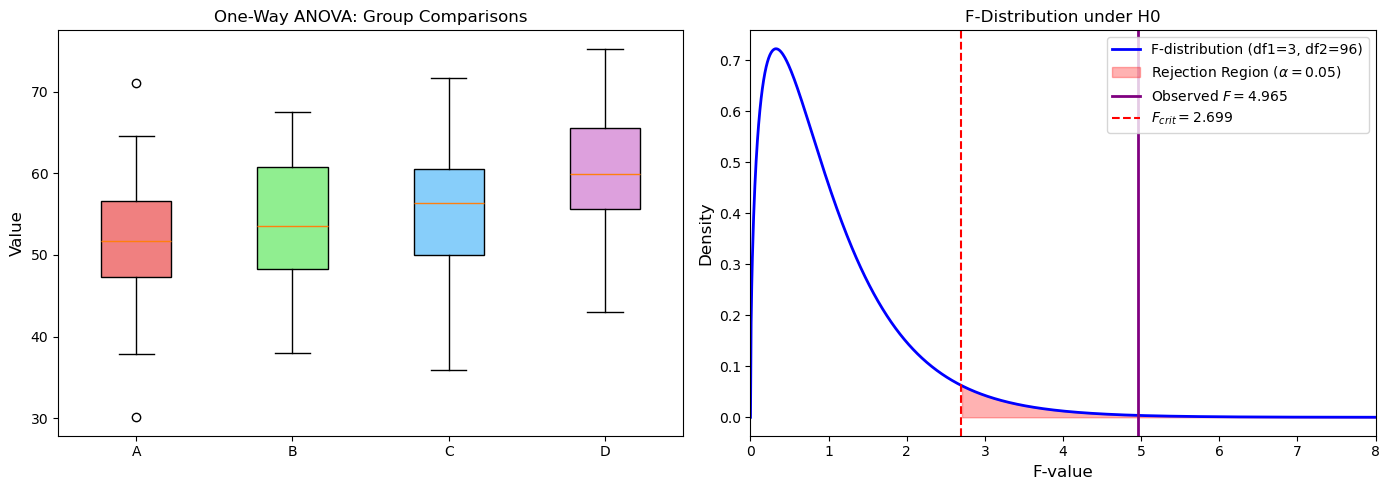

F-statistic: 4.9652 (manual: 4.9652)
p-value: 0.0030
Eta-squared (effect size): 0.1343
Decision at alpha=0.05: Reject H0


In [11]:
np.random.seed(6)
group_a = np.random.normal(50, 8, 25)
group_b = np.random.normal(55, 8, 25)
group_c = np.random.normal(53, 8, 25)
group_d = np.random.normal(60, 8, 25)

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(group_a, group_b, group_c, group_d)

# Manual calculations
all_data = np.concatenate([group_a, group_b, group_c, group_d])
grand_mean = np.mean(all_data)
n_total = len(all_data)
k = 4

# Sum of squares between groups
ss_between = (len(group_a)*(np.mean(group_a)-grand_mean)**2 +
              len(group_b)*(np.mean(group_b)-grand_mean)**2 +
              len(group_c)*(np.mean(group_c)-grand_mean)**2 +
              len(group_d)*(np.mean(group_d)-grand_mean)**2)

# Sum of squares within groups
ss_within = (np.sum((group_a - np.mean(group_a))**2) +
             np.sum((group_b - np.mean(group_b))**2) +
             np.sum((group_c - np.mean(group_c))**2) +
             np.sum((group_d - np.mean(group_d))**2))

df_between = k - 1
df_within = n_total - k
ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_manual = ms_between / ms_within

# Effect size: Eta-squared
eta_sq = ss_between / (ss_between + ss_within)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Group boxplots
ax1 = axes[0]
bp = ax1.boxplot([group_a, group_b, group_c, group_d],
                 tick_labels=['A', 'B', 'C', 'D'], patch_artist=True)
colors = ['lightcoral', 'lightgreen', 'lightskyblue', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('One-Way ANOVA: Group Comparisons', fontsize=12)

# Plot 2: F-distribution under H0
ax2 = axes[1]
x_f = np.linspace(0, 8, 1000)
y_f = stats.f.pdf(x_f, df_between, df_within)
ax2.plot(x_f, y_f, 'b-', lw=2, label=rf'F-distribution (df1={df_between}, df2={df_within})')

# Rejection region
f_crit = stats.f.ppf(0.95, df_between, df_within)
x_rej = x_f[x_f >= f_crit]
ax2.fill_between(x_rej, stats.f.pdf(x_rej, df_between, df_within),
                 alpha=0.3, color='red', label=rf'Rejection Region ($\alpha=0.05$)')

ax2.axvline(f_stat, color='purple', lw=2, label=rf'Observed $F = {f_stat:.3f}$')
ax2.axvline(f_crit, color='red', linestyle='--', lw=1.5, label=rf'$F_{{crit}} = {f_crit:.3f}$')
ax2.set_xlabel('F-value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('F-Distribution under H0', fontsize=12)
ax2.legend(loc='upper right')
ax2.set_xlim(0, 8)

plt.tight_layout()
plt.savefig('one_way_anova.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"F-statistic: {f_stat:.4f} (manual: {f_manual:.4f})")
print(f"p-value: {p_anova:.4f}")
print(f"Eta-squared (effect size): {eta_sq:.4f}")
print(f"Decision at alpha=0.05: {'Reject H0' if p_anova < 0.05 else 'Fail to reject H0'}")


## 7. Post-Hoc Testing: Tukey HSD

ANOVA only tells us that **at least one** group differs. **Tukey's Honestly Significant Difference (HSD)** tells us **which pairs** differ.

### How it works
Tukey compares all possible pairs of group means while controlling the **family-wise error rate** (the probability of making at least one Type I error across all comparisons).

### Output interpretation
- **meandiff**: Difference between group means
- **p-adj**: Adjusted p-value for that comparison
- **lower/upper**: Confidence interval for the difference
- **reject**: True if the CI excludes zero (significant difference)

> Always run post-hoc tests **only if** the overall ANOVA is significant.


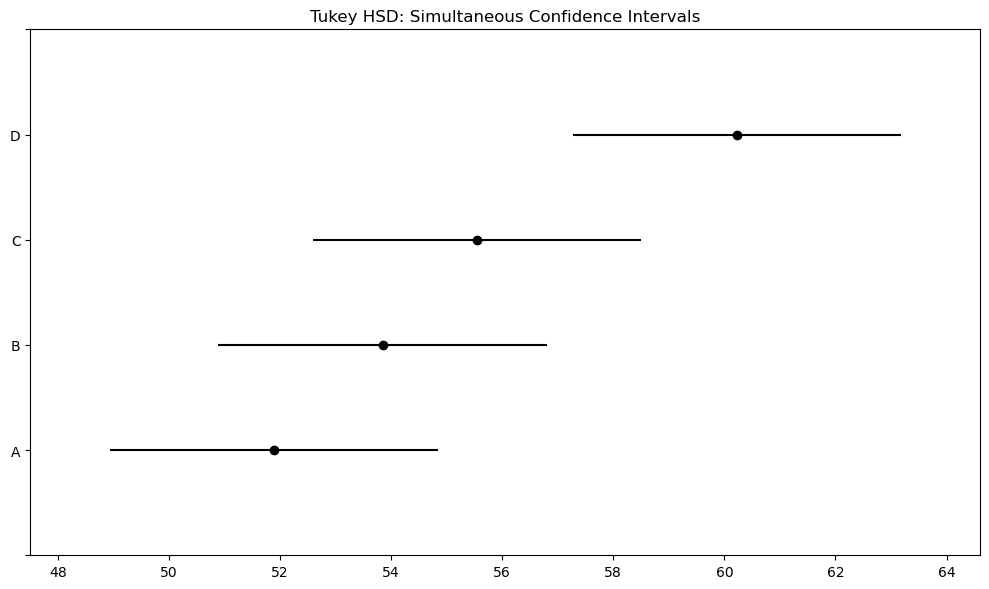

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   1.9596 0.8217 -3.9486  7.8677  False
     A      C   3.6576 0.3731 -2.2505  9.5657  False
     A      D   8.3355 0.0021  2.4273 14.2436   True
     B      C    1.698 0.8758 -4.2101  7.6061  False
     B      D   6.3759 0.0292  0.4678  12.284   True
     C      D   4.6779 0.1703 -1.2302  10.586  False
----------------------------------------------------


In [12]:
# Combine data from the ANOVA cell above
all_groups = np.concatenate([group_a, group_b, group_c, group_d])
labels = (['A'] * len(group_a) + ['B'] * len(group_b) +
          ['C'] * len(group_c) + ['D'] * len(group_d))

# Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(endog=all_groups, groups=labels, alpha=0.05)

fig, ax = plt.subplots(figsize=(8, 5))
tukey.plot_simultaneous(ax=ax)
ax.set_title('Tukey HSD: Simultaneous Confidence Intervals', fontsize=12)
plt.tight_layout()
plt.savefig('tukey_hsd.png', dpi=150, bbox_inches='tight')
plt.show()

print(tukey)


## 8. Two-Way ANOVA

Extends ANOVA to examine the effects of **two independent variables (factors)** simultaneously, plus their **interaction**.

### Sources of Variation
1. **Main Effect of Factor A**
2. **Main Effect of Factor B**
3. **Interaction Effect (A × B)**: Does the effect of Factor A depend on the level of Factor B?

### Example
Does study method (A vs. B) affect test scores, and does this effect differ between morning and evening sessions?

### The Interaction
If lines in an interaction plot are **parallel**, there is no interaction. If they **cross or diverge**, there is an interaction.


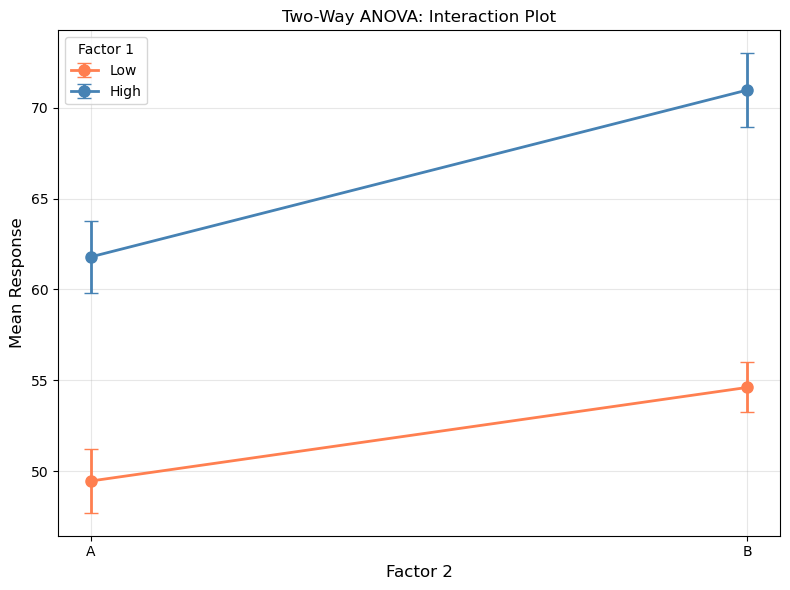

                            sum_sq    df          F        PR(>F)
C(Factor1)             1649.892988   1.0  63.713706  1.080337e-08
C(Factor2)              411.362485   1.0  15.885532  4.366654e-04
C(Factor1):C(Factor2)    32.534089   1.0   1.256365  2.718621e-01
Residual                725.071678  28.0        NaN           NaN


In [13]:
np.random.seed(7)
n = 8

# Factor levels
factor1 = np.repeat(['Low', 'High'], n * 2)
factor2 = np.tile(np.repeat(['A', 'B'], n), 2)

# Generate response with main effects and interaction
base = 50
eff1 = np.where(np.array(factor1) == 'High', 10, 0)
eff2 = np.where(np.array(factor2) == 'B', 5, 0)
interaction = np.where((np.array(factor1) == 'High') & (np.array(factor2) == 'B'), 8, 0)
noise = np.random.normal(0, 5, len(factor1))
response = base + eff1 + eff2 + interaction + noise

df = pd.DataFrame({'Factor1': factor1, 'Factor2': factor2, 'Response': response})

# Two-way ANOVA
model = ols('Response ~ C(Factor1) + C(Factor2) + C(Factor1):C(Factor2)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

fig, ax = plt.subplots(figsize=(8, 6))

# Interaction plot
for f1_val, color in zip(['Low', 'High'], ['coral', 'steelblue']):
    subset = df[df['Factor1'] == f1_val]
    means = [subset[subset['Factor2'] == f2]['Response'].mean() for f2 in ['A', 'B']]
    sems = [subset[subset['Factor2'] == f2]['Response'].sem() for f2 in ['A', 'B']]
    ax.errorbar(['A', 'B'], means, yerr=sems, marker='o', markersize=8,
                color=color, lw=2, capsize=5, label=f1_val)

ax.set_xlabel('Factor 2', fontsize=12)
ax.set_ylabel('Mean Response', fontsize=12)
ax.set_title('Two-Way ANOVA: Interaction Plot', fontsize=12)
ax.legend(title='Factor 1')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('two_way_anova.png', dpi=150, bbox_inches='tight')
plt.show()

print(anova_table)


## 9. Effect Sizes

Statistical significance tells us **whether** an effect exists. Effect size tells us **how large** the effect is — the practical importance.

### Cohen's d (for t-tests)

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$$

| d | Interpretation |
|---|----------------|
| 0.2 | Small |
| 0.5 | Medium |
| 0.8 | Large |

### Eta-squared (for ANOVA)

$$\eta^2 = \frac{SS_{between}}{SS_{total}}$$

| $\eta^2$ | Interpretation |
|----------|----------------|
| 0.01 | Small |
| 0.06 | Medium |
| 0.14 | Large |

> A result can be statistically significant (small p-value) but practically trivial (tiny effect size), especially with large samples.


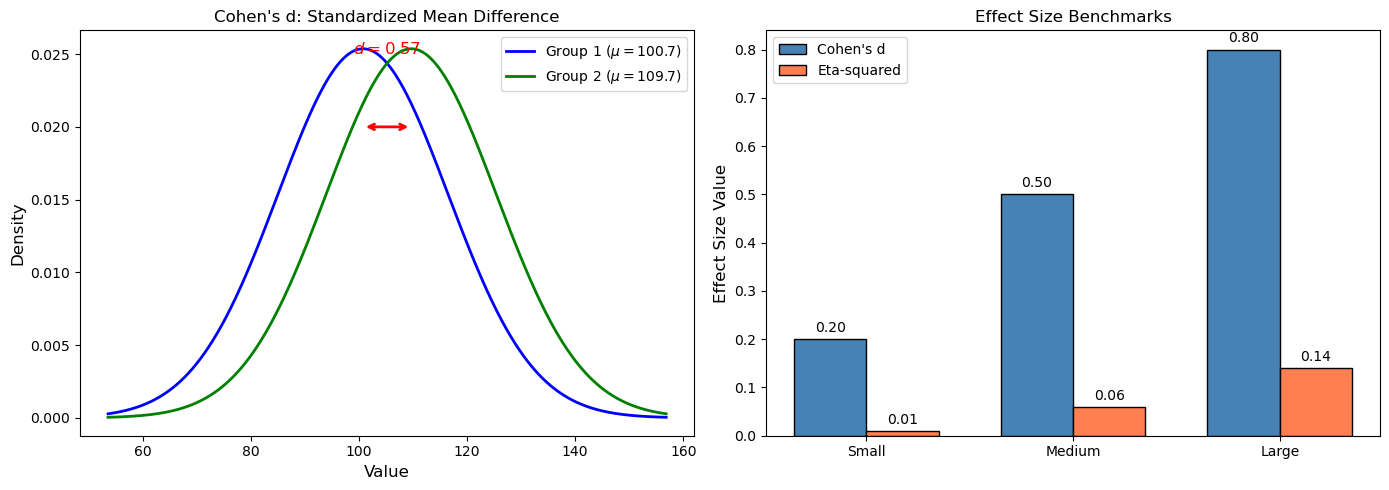

Cohen's d: 0.5667
Hedge's g: 0.5599
Eta-squared: 0.1399
Omega-squared: 0.1081

Interpretation (Cohen's d): 0.2=small, 0.5=medium, 0.8=large
Interpretation (Eta-sq):    0.01=small, 0.06=medium, 0.14=large


In [14]:
np.random.seed(8)
g1 = np.random.normal(100, 12, 30)
g2 = np.random.normal(110, 15, 35)

m1, m2 = np.mean(g1), np.mean(g2)
s1, s2 = np.std(g1, ddof=1), np.std(g2, ddof=1)
n1, n2 = len(g1), len(g2)

# Pooled Cohen's d
s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
cohens_d = (m2 - m1) / s_pooled

# Hedge's g (small-sample correction)
hedges_g = cohens_d * (1 - (3 / (4*(n1+n2) - 9)))

# Eta-squared from a 3-group ANOVA
a1 = np.random.normal(50, 8, 20)
a2 = np.random.normal(55, 8, 20)
a3 = np.random.normal(60, 8, 20)
all_a = np.concatenate([a1, a2, a3])
gm = np.mean(all_a)
ss_b = 20*(np.mean(a1)-gm)**2 + 20*(np.mean(a2)-gm)**2 + 20*(np.mean(a3)-gm)**2
ss_w = (np.sum((a1-np.mean(a1))**2) + np.sum((a2-np.mean(a2))**2) + np.sum((a3-np.mean(a3))**2))
ms_w = ss_w / (60 - 3)
eta_sq = ss_b / (ss_b + ss_w)
omega_sq = (ss_b - (3-1)*ms_w) / (ss_b + ss_w + ms_w)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cohen's d visualization
ax1 = axes[0]
x_d = np.linspace(m1 - 3*s_pooled, m2 + 3*s_pooled, 1000)
ax1.plot(x_d, stats.norm.pdf(x_d, m1, s_pooled), 'b-', lw=2, label=rf'Group 1 ($\mu={m1:.1f}$)')
ax1.plot(x_d, stats.norm.pdf(x_d, m2, s_pooled), 'g-', lw=2, label=rf'Group 2 ($\mu={m2:.1f}$)')
ax1.annotate('', xy=(m2, 0.02), xytext=(m1, 0.02),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text((m1+m2)/2, 0.025, rf"$d = {cohens_d:.2f}$", ha='center', color='red', fontsize=12)
ax1.set_title("Cohen's d: Standardized Mean Difference", fontsize=12)
ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend()

# Plot 2: Benchmark comparison
ax2 = axes[1]
effects = ['Small', 'Medium', 'Large']
d_values = [0.2, 0.5, 0.8]
eta_values = [0.01, 0.06, 0.14]
x_pos = np.arange(len(effects))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, d_values, width, label="Cohen's d",
                color='steelblue', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, eta_values, width, label='Eta-squared',
                color='coral', edgecolor='black')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(effects)
ax2.set_ylabel('Effect Size Value', fontsize=12)
ax2.set_title('Effect Size Benchmarks', fontsize=12)
ax2.legend()

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax2.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Hedge's g: {hedges_g:.4f}")
print(f"Eta-squared: {eta_sq:.4f}")
print(f"Omega-squared: {omega_sq:.4f}")
print("\nInterpretation (Cohen's d): 0.2=small, 0.5=medium, 0.8=large")
print("Interpretation (Eta-sq):    0.01=small, 0.06=medium, 0.14=large")


## 10. Power Analysis

**Statistical power** is the probability of correctly rejecting a false $H_0$.

### Factors Affecting Power
1. **Effect size**: Larger effects are easier to detect
2. **Sample size**: More data increases power
3. **Alpha level**: Higher $\alpha$ increases power (but more Type I errors)
4. **Variability**: Less noise increases power

### Standard Target
Researchers typically aim for **power $\geq$ 0.80** — an 80% chance of finding an effect if it truly exists.

### Sample Size Planning
Before running a study, use power analysis to determine how many participants you need to detect your expected effect size.


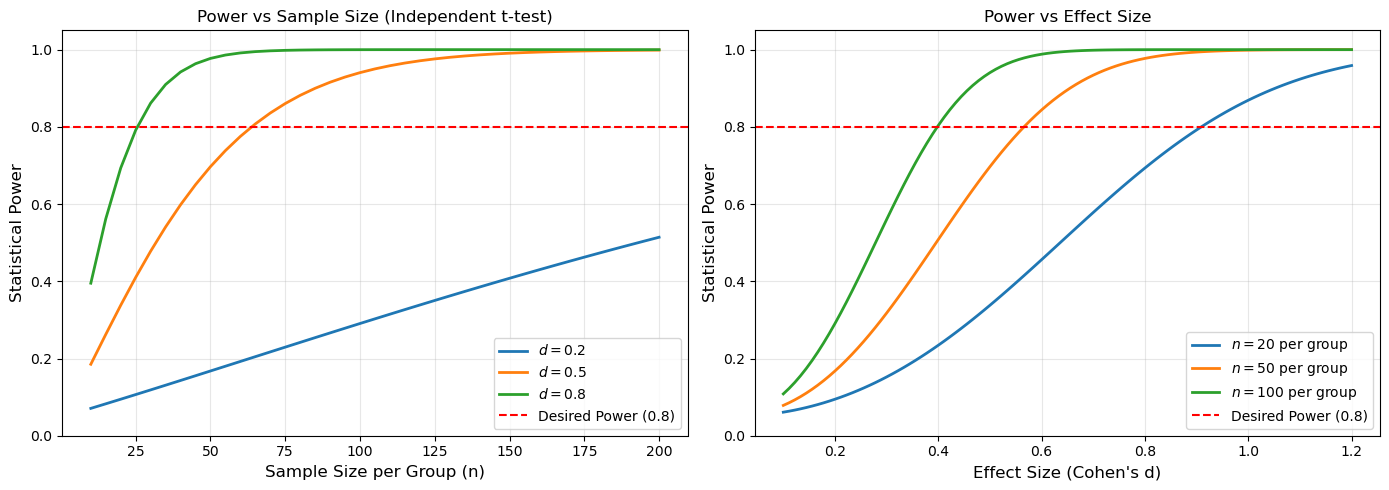

Required sample size per group (d=0.5, power=0.8, alpha=0.05): 64


In [15]:
power_analysis = TTestIndPower()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Power vs Sample Size
ax1 = axes[0]
effect_sizes = [0.2, 0.5, 0.8]
sample_sizes = np.arange(10, 201, 5)
for d in effect_sizes:
    powers = [power_analysis.power(effect_size=d, nobs1=n, ratio=1.0, alpha=0.05)
              for n in sample_sizes]
    ax1.plot(sample_sizes, powers, lw=2, label=rf"$d = {d}$")

ax1.axhline(0.8, color='red', linestyle='--', lw=1.5, label='Desired Power (0.8)')
ax1.set_xlabel('Sample Size per Group (n)', fontsize=12)
ax1.set_ylabel('Statistical Power', fontsize=12)
ax1.set_title('Power vs Sample Size (Independent t-test)', fontsize=12)
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Plot 2: Power vs Effect Size
ax2 = axes[1]
sample_sizes_demo = [20, 50, 100]
effect_range = np.linspace(0.1, 1.2, 100)
for n in sample_sizes_demo:
    powers = [power_analysis.power(effect_size=d, nobs1=n, ratio=1.0, alpha=0.05)
              for d in effect_range]
    ax2.plot(effect_range, powers, lw=2, label=rf"$n = {n}$ per group")

ax2.axhline(0.8, color='red', linestyle='--', lw=1.5, label='Desired Power (0.8)')
ax2.set_xlabel("Effect Size (Cohen's d)", fontsize=12)
ax2.set_ylabel('Statistical Power', fontsize=12)
ax2.set_title('Power vs Effect Size', fontsize=12)
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Required sample size for a typical study
n_required = power_analysis.solve_power(effect_size=0.5, power=0.8, alpha=0.05, ratio=1.0)
print(f"Required sample size per group (d=0.5, power=0.8, alpha=0.05): {int(np.ceil(n_required))}")


## 11. Summary: Choosing the Right Test

| Scenario | Test | Key Assumptions |
|----------|------|-----------------|
| One sample vs. known value | One-sample t-test | Normality, independence |
| Two independent groups | Independent t-test (Welch's) | Normality, independence |
| Same subjects, two time points | Paired t-test | Normality of differences, independence |
| Three+ groups, one factor | One-way ANOVA | Normality, equal variances, independence |
| Three+ groups, two factors | Two-way ANOVA | Normality, equal variances, independence |
| After significant ANOVA | Tukey HSD | Same as ANOVA |

### Remember
- **Never say "accept H0"** — we either reject H0 or fail to reject it
- **Always report effect sizes** alongside p-values
- **Check assumptions** before trusting parametric results
- **Plan your sample size** using power analysis before data collection
- 

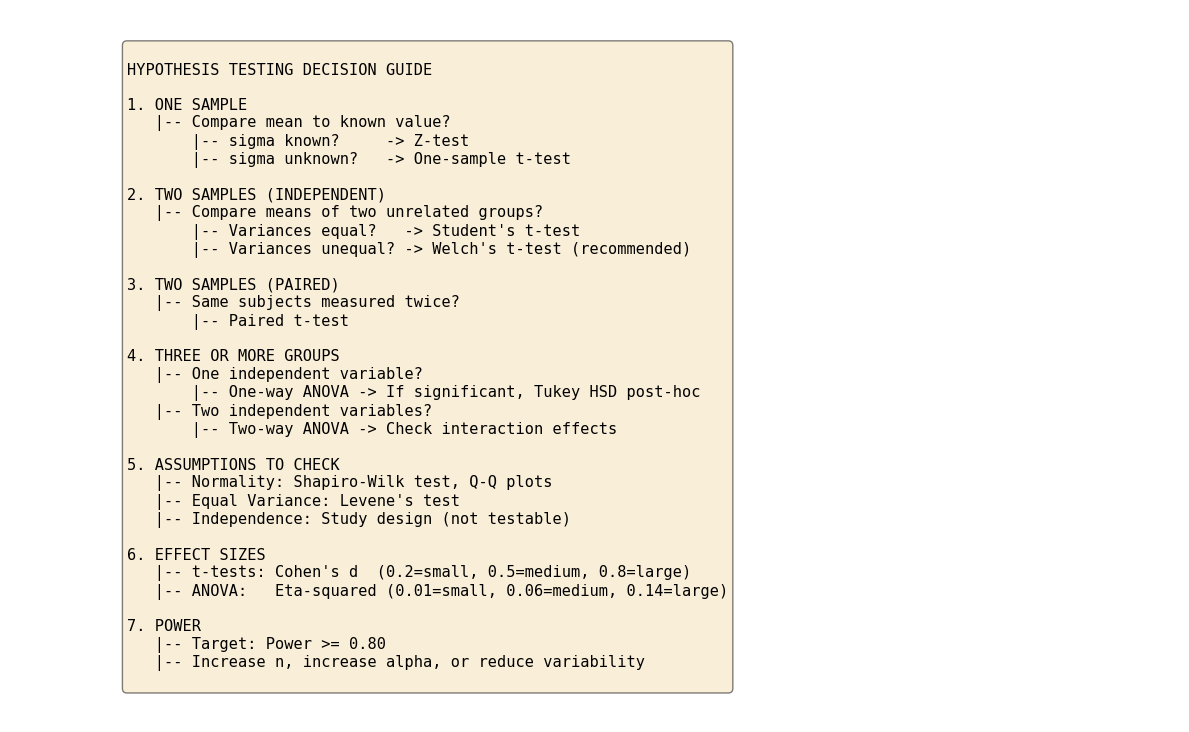

HYPOTHESIS TESTING NOTEBOOK COMPLETE
Generated visualizations:
  1. type_errors_power.png
  2. one_sample_ttest.png
  3. two_sample_ttest.png
  4. paired_ttest.png
  5. assumptions_check.png
  6. one_way_anova.png
  7. tukey_hsd.png
  8. two_way_anova.png
  9. effect_sizes.png
 10. power_analysis.png
 11. hypothesis_testing_summary.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

summary_text = """
HYPOTHESIS TESTING DECISION GUIDE

1. ONE SAMPLE
   |-- Compare mean to known value?
       |-- sigma known?     -> Z-test
       |-- sigma unknown?   -> One-sample t-test

2. TWO SAMPLES (INDEPENDENT)
   |-- Compare means of two unrelated groups?
       |-- Variances equal?   -> Student's t-test
       |-- Variances unequal? -> Welch's t-test (recommended)

3. TWO SAMPLES (PAIRED)
   |-- Same subjects measured twice?
       |-- Paired t-test

4. THREE OR MORE GROUPS
   |-- One independent variable?
       |-- One-way ANOVA -> If significant, Tukey HSD post-hoc
   |-- Two independent variables?
       |-- Two-way ANOVA -> Check interaction effects

5. ASSUMPTIONS TO CHECK
   |-- Normality: Shapiro-Wilk test, Q-Q plots
   |-- Equal Variance: Levene's test
   |-- Independence: Study design (not testable)

6. EFFECT SIZES
   |-- t-tests: Cohen's d  (0.2=small, 0.5=medium, 0.8=large)
   |-- ANOVA:   Eta-squared (0.01=small, 0.06=medium, 0.14=large)

7. POWER
   |-- Target: Power >= 0.80
   |-- Increase n, increase alpha, or reduce variability
"""

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('hypothesis_testing_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("HYPOTHESIS TESTING NOTEBOOK COMPLETE")
print("=" * 55)
print("Generated visualizations:")
print("  1. type_errors_power.png")
print("  2. one_sample_ttest.png")
print("  3. two_sample_ttest.png")
print("  4. paired_ttest.png")
print("  5. assumptions_check.png")
print("  6. one_way_anova.png")
print("  7. tukey_hsd.png")
print("  8. two_way_anova.png")
print("  9. effect_sizes.png")
print(" 10. power_analysis.png")
print(" 11. hypothesis_testing_summary.png")
